In [31]:
# All the imports 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [32]:
# Loading the datasets

students = pd.read_csv("../data/cs_students.csv")
job_postings = pd.read_csv("../data/job_market.csv")

# Just to check that we have the correct datasets
students.head(), job_postings.head()

(   Student ID           Name  Gender  Age  GPA             Major  \
 0           1     John Smith    Male   21  3.5  Computer Science   
 1           2  Alice Johnson  Female   20  3.2  Computer Science   
 2           3   Robert Davis    Male   22  3.8  Computer Science   
 3           4   Emily Wilson  Female   21  3.7  Computer Science   
 4           5  Michael Brown    Male   23  3.4  Computer Science   
 
          Interested Domain             Projects                 Future Career  \
 0  Artificial Intelligence  Chatbot Development   Machine Learning Researcher   
 1             Data Science       Data Analytics                Data Scientist   
 2     Software Development   E-commerce Website             Software Engineer   
 3          Web Development   Full-Stack Web App                 Web Developer   
 4            Cybersecurity     Network Security  Information Security Analyst   
 
     Python     SQL     Java  
 0   Strong  Strong     Weak  
 1  Average  Strong     Weak

In [33]:
# Counting the different domains students are interested in
students["Interested Domain"].value_counts()

Interested Domain
Artificial Intelligence           19
Web Development                   19
Cybersecurity                     18
Mobile App Development            17
Database Management               16
Cloud Computing                   16
Data Science                      13
Machine Learning                  13
Computer Graphics                 13
Software Development              11
Software Engineering               5
Bioinformatics                     2
Human-Computer Interaction         2
Biomedical Computing               2
Quantum Computing                  2
Network Security                   1
Game Development                   1
Computer Vision                    1
IoT (Internet of Things)           1
Natural Language Processing        1
Data Mining                        1
Blockchain Technology              1
Information Retrieval              1
Data Privacy                       1
Geographic Information Systems     1
Distributed Systems                1
Digital Forensics   

In [34]:
# Counting the different job categories there are postings for
job_postings["category"].value_counts()

category
Technology                     200
Remote                          11
Marketing and Communication      6
Software Development             4
Social Media Manager             2
Recruitment and Selection        1
SAP/ERP Consulting               1
Helpdesk                         1
Media Planning                   1
Finance                          1
Process Engineering              1
HR                               1
Name: count, dtype: int64

In [35]:
# 1: See if a student's interested doamins maps to a job category (manually)

domain_to_category = {
    # Core CS / AI / Data
    "Artificial Intelligence": "Technology",
    "Machine Learning": "Technology",
    "Data Science": "Technology",
    "Data Mining": "Technology",
    "Natural Language Processing": "Technology",
    "Computer Vision": "Technology",
    "Information Retrieval": "Technology",
    "Data Privacy": "Technology",
    "Bioinformatics": "Technology",
    "Biomedical Computing": "Technology",
    "Geographic Information Systems": "Technology",
    "Quantum Computing": "Technology",

    # Software / Web / Mobile
    "Web Development": "Software Development",
    "Software Development": "Software Development",
    "Software Engineering": "Software Development",
    "Mobile App Development": "Software Development",
    "Game Development": "Software Development",
    "Computer Graphics": "Software Development",
    "Human-Computer Interaction": "Software Development",

    # Systems / Infra / Security / Cloud
    "Cybersecurity": "Technology",
    "Network Security": "Technology",
    "Digital Forensics": "Technology",
    "Cloud Computing": "Technology",
    "Distributed Systems": "Technology",
    "IoT (Internet of Things)": "Technology",
    "Blockchain Technology": "Technology",
    "Database Management": "Technology"
}

students["mapped_category"] = students["Interested Domain"].map(domain_to_category)
students["mapped_category"].value_counts()

mapped_category
Technology              112
Software Development     68
Name: count, dtype: int64

In [36]:
# 2: Comparing the difficulty by the mapped categories
job_postings["salary_avg"] = (job_postings["salary_min"] + job_postings["salary_max"]) / 2

def count_skills(s):
    if isinstance(s, str):
        return len([x.strip() for x in s.split(",")])
    return 0

job_postings["num_skills"] = job_postings["skills"].apply(count_skills)

size_map = {
    "1-50 employees": 0,
    "51-200 employees": 1,
    "201-500 employees": 2,
    "500+ employees": 3
}

job_postings["company_size_clean"] = job_postings["company_size"].fillna("Unknown")

job_postings["difficulty_score"] = (
    1.2 * job_postings["num_skills"]
    + 2.0 * job_postings["experience_required"]
    + 0.0005 * job_postings["salary_avg"]
    + job_postings["company_size_clean"].map(size_map).fillna(1)
)

# Aggregate difficulty by category
difficulty_by_cat = job_postings.groupby("category")["difficulty_score"].mean().sort_values(ascending=False)
difficulty_by_cat


category
Remote                         83.000000
Technology                     79.416164
Recruitment and Selection      75.000000
Finance                              NaN
HR                                   NaN
Helpdesk                             NaN
Marketing and Communication          NaN
Media Planning                       NaN
Process Engineering                  NaN
SAP/ERP Consulting                   NaN
Social Media Manager                 NaN
Software Development                 NaN
Name: difficulty_score, dtype: float64

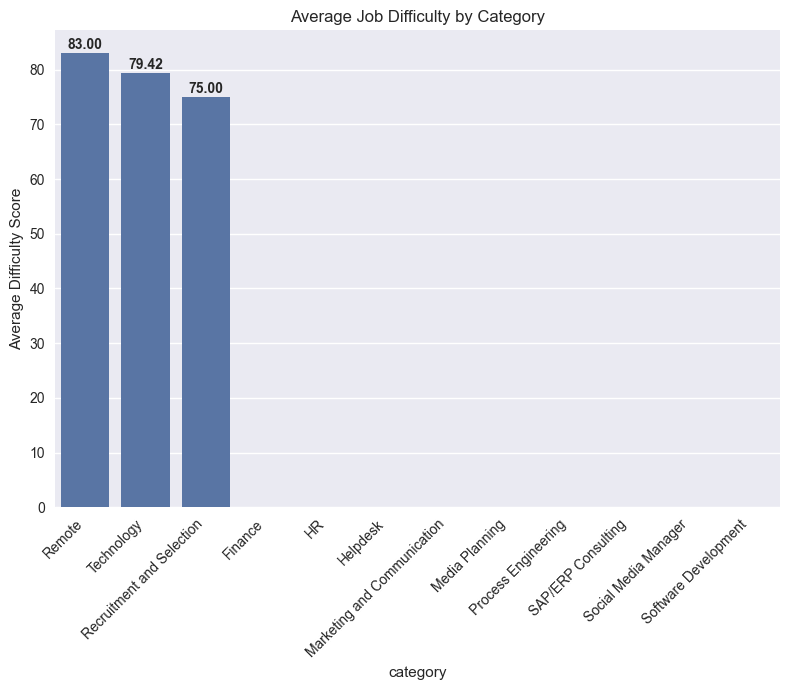

In [37]:
# Plot it

plt.figure(figsize=(8,7))
axis = sns.barplot(x=difficulty_by_cat.index, y=difficulty_by_cat.values)

for i, value in enumerate(difficulty_by_cat.values):
    axis.text(
        i,
        value + 0.2,
        f"{value:.2f}",
        ha="center", 
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Difficulty Score")
plt.title("Average Job Difficulty by Category")
plt.tight_layout()
plt.show()